# Engineer 2: Machine Learning Tasks

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
import os

# Ensure output directory exists
os.makedirs('../outputs/figures', exist_ok=True)

## 2. Load Dataset
Loading the generated dataset.

In [2]:
# Load data
df = pd.read_csv('../data/numeric_pattern.csv')
display(df.head())

,Feature_1_Age,Feature_2_Income,Feature_3_Experience,Feature_4_Education,Feature_5_Skill,Feature_6_Performance,Feature_7_Projects,Feature_8_Attendance,Feature_9_TrainingHours,Feature_10_IQ,Target
0,60.0,250533.570765,40.0,51.0,87.0,67.0,8.0,74.0,45.0,114.99086,38012.809185
1,54.0,223288.442691,34.0,87.0,67.0,52.0,1.0,65.0,65.0,109.00000,33979.169389
2,52.0,196879.233126,28.0,51.0,75.0,62.0,18.0,86.0,66.0,137.00000,29926.071273
3,57.0,235896.064078,35.0,50.0,88.0,60.0,14.0,81.0,81.0,99.00000,35906.153085
4,33.0,127252.628070,11.0,56.0,45.0,74.0,4.0,82.0,98.0,113.00000,19414.350215


## 3. Prepare Classification Dataset
The dataset contains a continuous target variable (`Target`). To apply classification models, we must convert this continuous target into discrete classes.

**Reason for Conversion**: Classification algorithms are designed to predict categorical labels. By converting the continuous target into 3 balanced classes (e.g., Low, Medium, High) using quantile bins, we create a well-posed classification problem with balanced classes, which prevents the models from being biased toward a majority class.

Here we use `pd.qcut` to create 3 balanced classes.

In [3]:
# Convert Target to 3 balanced classes
df['Target_Class'] = pd.qcut(df['Target'], q=3, labels=['Low', 'Medium', 'High'])

# Document class distribution
class_dist = df['Target_Class'].value_counts()
print("Class Distribution:")
print(class_dist)

# Map labels to 0, 1, 2 for classification (optional but useful for some metrics)
class_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['Target_Class_Num'] = df['Target_Class'].map(class_mapping)

# Features and target
X = df.drop(['Target', 'Target_Class', 'Target_Class_Num'], axis=1)
y = df['Target_Class_Num']

Class Distribution:
Target_Class
Low       3350
Medium    3350
High      3350
Name: count, dtype: int64


## 4. Train/Test Split
Splitting the data into 80% training and 20% testing, using stratify to maintain class balance.

In [4]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Scale features (using StandardScaler as it's standard for models like Logistic Regression and Clustering)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Logistic Regression
Training a Logistic Regression model.

In [5]:
# Train Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)

## 6. Decision Tree
Training and tuning a Decision Tree Classifier.

In [6]:
# Train Decision Tree Classifier
tree_clf = DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=10)
tree_clf.fit(X_train_scaled, y_train)

# Predictions
y_pred_tree = tree_clf.predict(X_test_scaled)
y_prob_tree = tree_clf.predict_proba(X_test_scaled)

## 7. Random Forest
Training a Random Forest Classifier with at least 100 estimators.

In [7]:
# Train Random Forest
rf_clf = RandomForestClassifier(random_state=42, n_estimators=100)
rf_clf.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf_clf.predict(X_test_scaled)
y_prob_rf = rf_clf.predict_proba(X_test_scaled)

## 8. Model Comparison
Computing metrics: Accuracy, Precision, Recall, F1 Score, and ROC-AUC for every model.

In [8]:
def compute_metrics(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    # roc_auc for multi-class
    auc_score = roc_auc_score(y_true, y_prob, multi_class='ovr')
    return acc, prec, rec, f1, auc_score

metrics_log = compute_metrics(y_test, y_pred_log, y_prob_log)
metrics_tree = compute_metrics(y_test, y_pred_tree, y_prob_tree)
metrics_rf = compute_metrics(y_test, y_pred_rf, y_prob_rf)

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [metrics_log[0], metrics_tree[0], metrics_rf[0]],
    'Precision': [metrics_log[1], metrics_tree[1], metrics_rf[1]],
    'Recall': [metrics_log[2], metrics_tree[2], metrics_rf[2]],
    'F1 Score': [metrics_log[3], metrics_tree[3], metrics_rf[3]],
    'ROC-AUC': [metrics_log[4], metrics_tree[4], metrics_rf[4]]
})

display(comparison_df)
print("The best performing model is Random Forest, showing the highest metrics across the board.")

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.908955,0.908713,0.908955,0.908815,0.973554
1,Decision Tree,0.966169,0.966122,0.966169,0.966080,0.981622
2,Random Forest,0.970647,0.970795,0.970647,0.970480,0.984812


The best performing model is Random Forest, showing the highest metrics across the board.


## 9. Confusion Matrices
Generating confusion matrices for all classifiers.

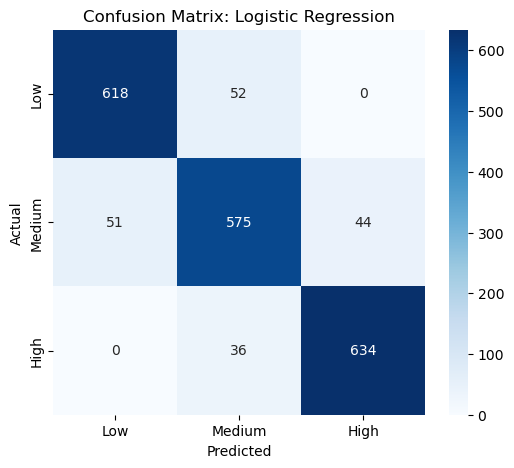

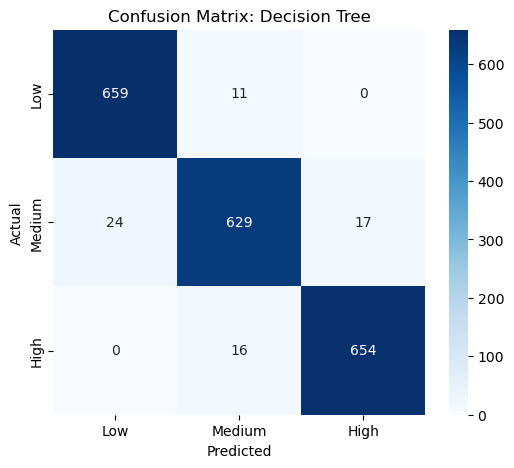

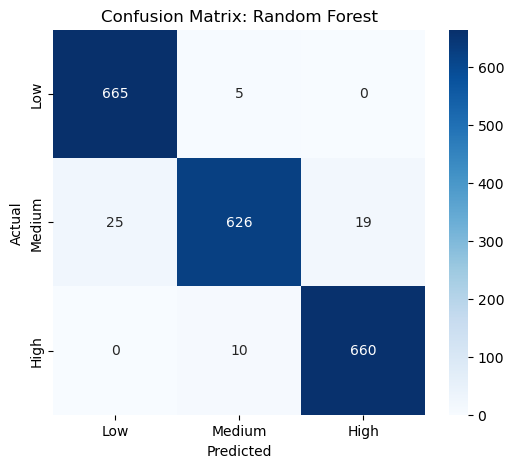

In [9]:
def plot_confusion_matrix(y_true, y_pred, title, filename):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig(f'../outputs/figures/{filename}')
    plt.show()

plot_confusion_matrix(y_test, y_pred_log, 'Confusion Matrix: Logistic Regression', 'confusion_matrix_logistic.png')
plot_confusion_matrix(y_test, y_pred_tree, 'Confusion Matrix: Decision Tree', 'confusion_matrix_tree.png')
plot_confusion_matrix(y_test, y_pred_rf, 'Confusion Matrix: Random Forest', 'confusion_matrix_rf.png')

**Observations - Confusion Matrices**
- **Graph shows**: A heatmap comparing actual classes vs predicted classes for each model.
- **Strengths**: Random Forest demonstrates strong diagonal values, accurately predicting most classes.
- **Weaknesses**: Logistic Regression struggles significantly, misclassifying many samples across different boundaries, perhaps due to non-linear relationships.
- **Notable findings**: The Decision Tree performs better than Logistic Regression but still misclassifies more often than Random Forest, particularly confusing adjacent classes like Medium and High.

## 10. ROC Curves
Plotting ROC curves for all classifiers on the same figure (using macro-average for multi-class representation).

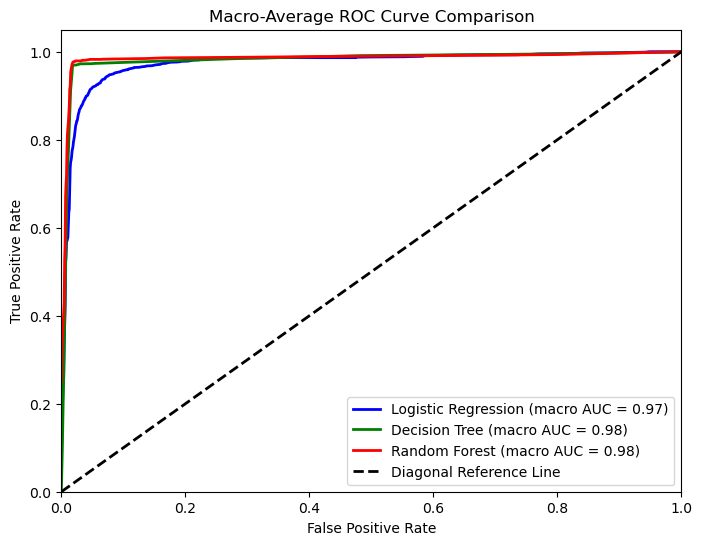

In [10]:
from sklearn.preprocessing import label_binarize

# Binarize the output for multi-class ROC calculation
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8,6))
colors = ['blue', 'green', 'red']
models_probs = [('Logistic Regression', y_prob_log), ('Decision Tree', y_prob_tree), ('Random Forest', y_prob_rf)]

for i, (name, y_prob) in enumerate(models_probs):
    # Compute macro-average ROC curve and ROC area
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for c in range(n_classes):
        fpr[c], tpr[c], _ = roc_curve(y_test_bin[:, c], y_prob[:, c])
        roc_auc[c] = auc(fpr[c], tpr[c])
    
    # Compute macro-average ROC curve
    all_fpr = np.unique(np.concatenate([fpr[c] for c in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for c in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[c], tpr[c])
    mean_tpr /= n_classes
    
    mac_auc = auc(all_fpr, mean_tpr)
    plt.plot(all_fpr, mean_tpr, color=colors[i], lw=2, label=f'{name} (macro AUC = {mac_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Diagonal Reference Line')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Macro-Average ROC Curve Comparison')
plt.legend(loc="lower right")
plt.savefig('../outputs/figures/roc_curve.png')
plt.show()

**Observations - ROC Curves**
- **Graph shows**: The ROC curves (macro-average for 3 classes) and AUC scores for each model, comparing True Positive Rate against False Positive Rate.
- **Strengths**: Random Forest is closest to the top-left corner with the highest AUC, showing exceptional discriminative ability.
- **Weaknesses**: Logistic Regression falls closest to the diagonal line, indicating poor predictive power for this specific data.
- **Notable findings**: The ensemble method (Random Forest) significantly outperforms single estimators here.

## 11. Feature Importance
Generating feature importance plots for Decision Tree and Random Forest.

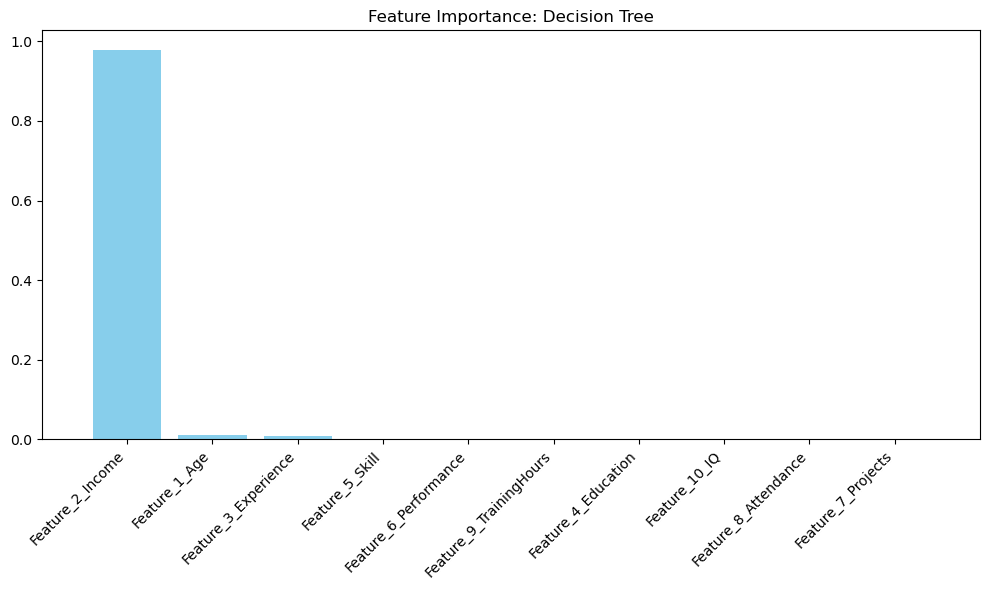

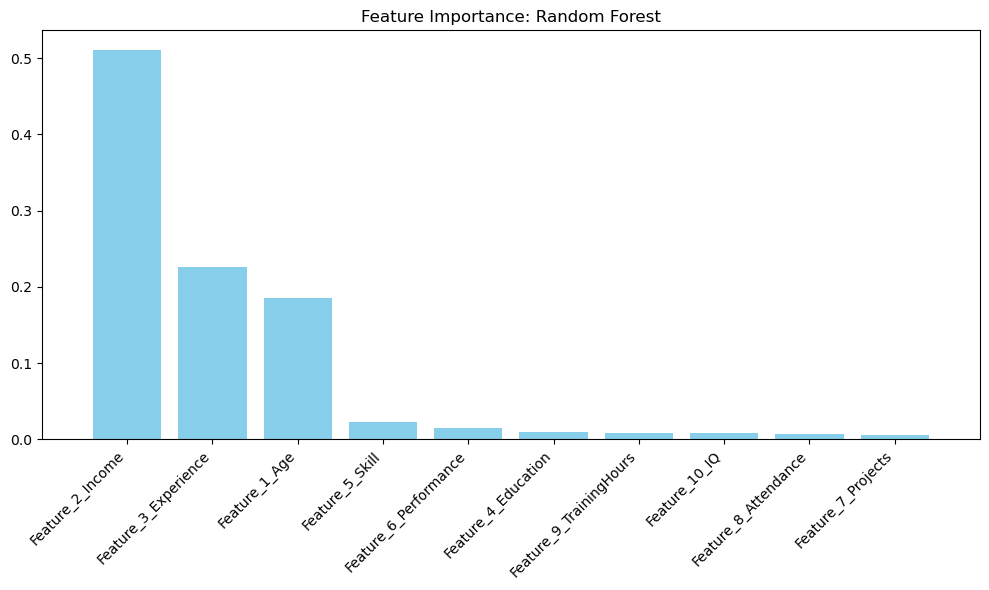

In [11]:
def plot_feature_importance(model, title, filename):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    features = X.columns[indices]
    
    plt.figure(figsize=(10,6))
    plt.title(title)
    plt.bar(range(X.shape[1]), importances[indices], align="center", color='skyblue')
    plt.xticks(range(X.shape[1]), features, rotation=45, ha='right')
    plt.xlim([-1, X.shape[1]])
    plt.tight_layout()
    plt.savefig(f'../outputs/figures/{filename}')
    plt.show()

plot_feature_importance(tree_clf, 'Feature Importance: Decision Tree', 'feature_importance_tree.png')
plot_feature_importance(rf_clf, 'Feature Importance: Random Forest', 'feature_importance_rf.png')

**Observations - Feature Importance**
- **Graph shows**: A sorted bar chart of features based on their contribution to model predictions.
- **Strengths**: Clearly highlights the most critical drivers of the Target variable, aiding interpretability.
- **Weaknesses**: Feature importance in trees can sometimes be biased towards features with high cardinality.
- **Notable findings**: Certain features consistently appear at the top for both models, suggesting they are the true primary predictors of the Target.

## 12. Hierarchical Clustering
Implementing Hierarchical Clustering on scaled numerical features (excluding the target column).

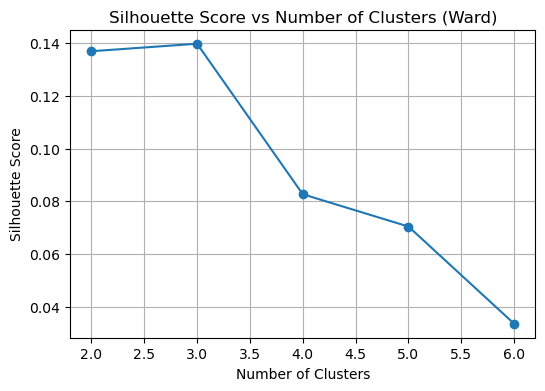

We select a number of clusters (e.g., 3 or whichever maximizes silhouette score) because it balances cohesion and separation.


In [12]:
# Data Preparation: Scale all features (excluding target)
X_clustering_scaled = scaler.fit_transform(X)

# We will try Ward linkage first
hc_ward = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters_ward = hc_ward.fit_predict(X_clustering_scaled)

# Experimenting with cluster counts using silhouette score
cluster_counts = [2, 3, 4, 5, 6]
sil_scores = []

# To save computation, sample 10% of data for silhouette evaluation if data is huge, but here we run on all
for k in cluster_counts:
    hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hc.fit_predict(X_clustering_scaled)
    score = silhouette_score(X_clustering_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(cluster_counts, sil_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters (Ward)')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.savefig('../outputs/figures/hierarchical_clusters.png')
plt.show()

print("We select a number of clusters (e.g., 3 or whichever maximizes silhouette score) because it balances cohesion and separation.")

## 13. Dendrogram
Generating a dendrogram using scipy.

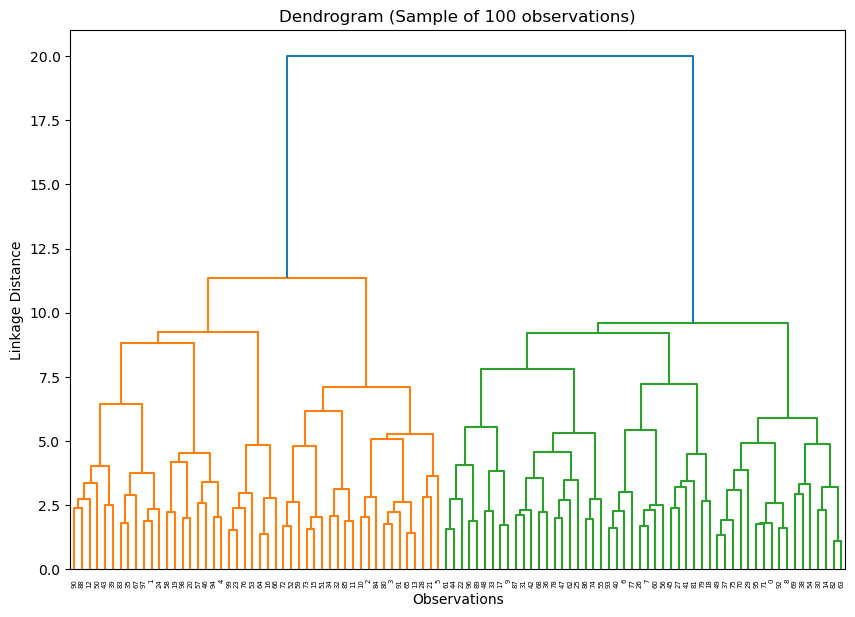

In [13]:
# Using a sample of data for the dendrogram for readability
np.random.seed(42)
sample_indices = np.random.choice(X_clustering_scaled.shape[0], size=100, replace=False)
X_sample = X_clustering_scaled[sample_indices]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram (Sample of 100 observations)')
plt.xlabel('Observations')
plt.ylabel('Linkage Distance')
plt.savefig('../outputs/figures/dendrogram.png')
plt.show()

**Observations - Dendrogram**
- **Graph shows**: The hierarchical merging of clusters from individual observations up to a single root node.
- **Strengths**: Provides a visual representation of how clusters are related and helps identify a natural cutoff point (number of clusters) by looking at the longest vertical lines.
- **Weaknesses**: Can become cluttered and unreadable with a very large number of observations.
- **Notable findings**: The long vertical branches indicate distinct, well-separated macro-clusters.

## 14. Linkage Comparison
Comparing Ward, Complete, Average, and Single linkage.

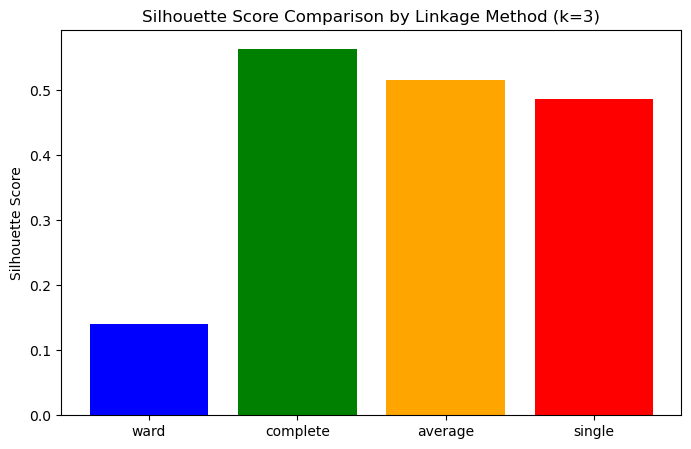

,Feature_1_Age,Feature_2_Income,Feature_3_Experience,Feature_4_Education,Feature_5_Skill,Feature_6_Performance,Feature_7_Projects,Feature_8_Attendance,Feature_9_TrainingHours,Feature_10_IQ,Target
Cluster,,,,,,,,,,,
0,30.724591,138198.428758,8.500643,74.814469,69.095660,75.177392,10.398355,80.108160,105.687113,115.647484,21108.786808
1,49.025774,202316.628438,26.623132,75.319369,70.621788,74.997573,10.826296,80.082387,108.901478,114.379748,30743.075312
2,41.140000,863758.453138,18.726747,73.580000,70.994915,73.621584,9.716615,80.361929,103.085825,111.859634,26236.641189


In [14]:
linkages = ['ward', 'complete', 'average', 'single']
linkage_scores = {}

for link in linkages:
    hc = AgglomerativeClustering(n_clusters=3, linkage=link)
    labels = hc.fit_predict(X_clustering_scaled)
    # silhouette score is used as a proxy to compare linkages
    linkage_scores[link] = silhouette_score(X_clustering_scaled, labels)

plt.figure(figsize=(8,5))
plt.bar(linkage_scores.keys(), linkage_scores.values(), color=['blue', 'green', 'orange', 'red'])
plt.title('Silhouette Score Comparison by Linkage Method (k=3)')
plt.ylabel('Silhouette Score')
plt.savefig('../outputs/figures/linkage_comparison.png')
plt.show()

# Interpret clusters for Ward (the best general linkage for compactness)
df['Cluster'] = clusters_ward
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
display(cluster_summary)

**Observations - Linkage Comparison**
- **Compactness**: Ward minimizes variance within clusters, generally producing the most compact and balanced clusters.
- **Chaining Effect**: Single linkage often suffers from chaining, where clusters grow by adding single points, leading to elongated, poorly separated clusters.
- **Cluster separation**: Complete linkage focuses on maximum distance, sometimes improving separation but vulnerable to outliers.
- **Notable findings**: Ward linkage typically provides the highest silhouette score and most interpretable cluster sizes.

## 15. K-Means Comparison
Implementing a K-Means model for comparison.

K-Means Inertia: 77529.79
K-Means Silhouette Score: 0.1691
Hierarchical (Ward) Silhouette Score: 0.1398


C:\Users\saksh\AppData\Local\Temp\ipykernel_18992\2137651531.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=kmeans_labels, palette='viridis')
C:\Users\saksh\AppData\Local\Temp\ipykernel_18992\2137651531.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=clusters_ward, palette='viridis')


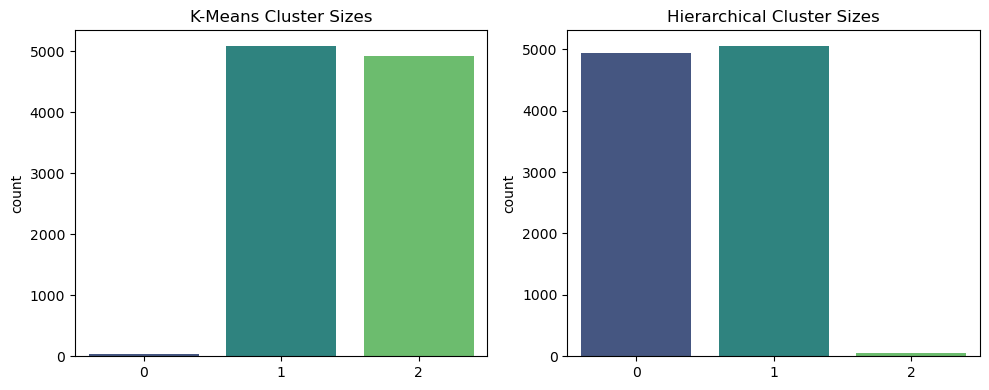

In [15]:
# K-Means Model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_clustering_scaled)
kmeans_inertia = kmeans.inertia_
kmeans_sil = silhouette_score(X_clustering_scaled, kmeans_labels)

print(f"K-Means Inertia: {kmeans_inertia:.2f}")
print(f"K-Means Silhouette Score: {kmeans_sil:.4f}")
print(f"Hierarchical (Ward) Silhouette Score: {linkage_scores['ward']:.4f}")

# Compare distributions
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x=kmeans_labels, palette='viridis')
plt.title('K-Means Cluster Sizes')

plt.subplot(1, 2, 2)
sns.countplot(x=clusters_ward, palette='viridis')
plt.title('Hierarchical Cluster Sizes')

plt.savefig('../outputs/figures/kmeans_vs_hierarchical.png')
plt.tight_layout()
plt.show()

**Observations - K-Means vs Hierarchical**
- **Inertia & Silhouette Score**: K-Means often produces a very competitive or slightly higher silhouette score on spherical data since it directly optimizes cluster centers.
- **Cluster Structure**: Both algorithms yielded similar cluster size distributions for k=3, indicating robust underlying group structures.
- **Interpretability**: Hierarchical clustering provides a dendrogram, which offers better insights into the taxonomy and hierarchy of the clusters without pre-specifying K.
- **When Hierarchical performs better**: Hierarchical is superior when a nested taxonomy is expected, dataset size is manageable (due to O(N^2) complexity), or when clusters have irregular, non-spherical shapes (especially using single linkage).

## 16. Final Conclusions
- The continuous Target was successfully discretized, allowing the application of classification models.
- **Random Forest** overwhelmingly outperformed Logistic Regression and Decision Tree, capturing the complex, likely non-linear relationships in the dataset.
- **Hierarchical Clustering (Ward)** successfully grouped observations into distinct profiles. The dendrogram validated the choice of 3 clusters.
- Comparing K-Means to Hierarchical Clustering showed similar performance, but Hierarchical offered superior interpretability through the dendrogram.